# Variational inference and model checking

CPU companion; no accelerator is required. TPU execution not validated.

- Derive the diagonal Gaussian variational optimum for a correlated target
- Separate optimization error from variational-family error
- Use reparameterization to inspect a Monte Carlo objective
- Diagnose mean-function mismatch using predictive residuals

A variational optimizer finishes with a stable objective, and its posterior mean agrees with a reference. Can its uncertainty still be wrong? We will optimize a diagonal Gaussian against a correlated exact target, then check a prediction under a deliberately misspecified observation model. These are two different failure sources: an inference approximation and a model assumption.

## The idea

Variational inference chooses a tractable family $q$ and adjusts it to approximate a posterior $p$. Our objective is $\operatorname{KL}(q\Vert p)$, available exactly for this Gaussian fixture. In a general model the evidence lower bound, or ELBO, replaces the unknown posterior normalization. A successful optimizer can only find distributions inside its chosen family.

## Name the approximation and the KL direction

The target covariance has unit marginal variances and correlation $0.8$. Our variational family has a location $a$ and diagonal covariance $D$. It cannot tilt its uncertainty ellipse. The KL direction matters: minimizing $\operatorname{KL}(q\Vert p)$ penalizes placing probability where the target density is low. For this Gaussian target, optimizing over diagonal $D$ gives $a=m$ and $D_{ii}=1/P_{ii}$, where $P=\Sigma^{-1}$. Those are conditional-variance quantities, not the target marginal variances.

$$
\operatorname{KL}(q\Vert p)=\frac12\left[\operatorname{tr}(PD)+(a-m)^\top P(a-m)-d+\log|\Sigma|-\log|D|\right]
$$

## Work through the remaining error

For correlation $0.8$, the covariance determinant is $1-0.8^2=0.36$, and each diagonal precision is $1/0.36$. The optimal diagonal variance is therefore $0.36$. Each standard deviation is $0.6$, whereas the target marginal standard deviations are $1$. The means can be right while uncertainty is too narrow. At this optimum the KL is about $0.5108$, not zero. More optimization cannot remove that family restriction.

## Connect the exact objective to an ELBO

In a model with data $y$ and latent parameters $w$, the ELBO is the expectation of $\log p(y,w)-\log q(w)$ under $q$. The gap to log evidence is $\operatorname{KL}(q\Vert p(w\mid y))$. Reparameterize a diagonal normal as $w=a+\exp(s)\odot\epsilon$, with standard-normal $\epsilon$, to differentiate an estimated objective with respect to $a,s$. Our exact objective avoids Monte Carlo noise so the family restriction is clear. The experiment below estimates the same KL with independent random draws and compares it to the analytic value.

$$
\log p(y)-\operatorname{ELBO}(q)=\operatorname{KL}(q(w)\Vert p(w\mid y))
$$

## Inspect what the model predicts, not only its optimizer

A posterior predictive check draws plausible replicated observations and compares meaningful features with the observed data. Choose a discrepancy such as residual curvature, outlier count or group-specific spread; a single global mean can conceal a failure. Our stress fixture uses a zero linear mean and noise standard deviation $0.25$, then supplies targets $x^2-1$. Positive residuals at both ends and negative residuals near the center reveal curvature missing from the mean model. Narrower intervals cannot repair that pattern.

## Keep inference and model errors separate

The first experiment has a correct known target but an inadequate variational family. The second deliberately changes the data-generating mean while retaining an inadequate likelihood. Posterior predictive checks can reveal tension but do not certify model truth. For a real workflow, choose checks before inspecting a final held-out split, keep group sizes and uncertainty in reported coverage, and refit only on permitted data. A NumPyro SVI or NUTS implementation is an ecosystem bridge; this lesson does not claim those optional APIs were executed.

## 1. Specify a correlated target and a simpler approximation

Create a fresh main.py. Our target is an exactly known Gaussian so approximation error can be measured independently of optimization error.

In [1]:
import numpy as np
import jax
import jax.numpy as jnp
mu=jnp.array([1.,-1.])
Sigma=jnp.array([[1.,.8],[.8,1.]])
P=jnp.linalg.solve(Sigma,jnp.eye(2))
def kl(params):
    location,log_scale=params
    variance=jnp.exp(2*log_scale)
    delta=location-mu
    return .5*(jnp.sum(jnp.diag(P)*variance)+delta@P@delta-2+jnp.linalg.slogdet(Sigma)[1]-jnp.sum(2*log_scale))

KL here means KL(q || p). The full covariance of p is retained, while q has independent coordinates.

## 2. Optimize and compare to the exact variational optimum

Append a scan of gradient updates. The analytic optimum uses inverse diagonal precision, which differs from the target marginal variances.

In [2]:
def update(params,_):
    grads=jax.grad(kl)(params)
    new=jax.tree.map(lambda value,grad:value-.05*grad,params,grads)
    return new,kl(new)
params,history=jax.lax.scan(update,(jnp.zeros(2),jnp.zeros(2)),None,length=600)
location,log_scale=params
variance=jnp.exp(2*log_scale)
assert jnp.allclose(location,mu,atol=1e-4)
assert jnp.allclose(variance,1/jnp.diag(P),atol=1e-5)
assert jnp.allclose(variance,jnp.array([.36,.36]),atol=1e-5)
assert kl(params)>0.4
print('VI mean:',location,'variances:',variance,'remaining KL:',float(kl(params)))

VI mean: [ 0.99999994 -0.99999994] variances: [0.36000016 0.36000016] remaining KL: 0.5108256340026855


Optimization has found the best diagonal Gaussian in this KL direction, yet it cannot reproduce target correlation.

## 3. Check a prediction under a changed data-generating process

Append an explicit model-mismatch experiment. The fitted line predicts zero, but new synthetic targets have curvature. Standardized residuals expose the missing structure.

In [3]:
x=jnp.linspace(-2,2,9)
linear_mean=jnp.zeros_like(x)
noise_scale=.25
curved_targets=x**2-1.
standardized_residual=(curved_targets-linear_mean)/noise_scale
coverage=jnp.mean(jnp.abs(standardized_residual)<=1.96)
assert coverage<.4
assert standardized_residual[0]>10
print('synthetic nominal-95% interval coverage:',float(coverage))
print('standardized residuals:',standardized_residual)

synthetic nominal-95% interval coverage: 0.2222222238779068
standardized residuals: [12.  5.  0. -3. -4. -3.  0.  5. 12.]


This is a deterministic stress fixture with nine targets, not an estimate of population coverage. It isolates a mean-function mismatch that more posterior draws cannot repair.

## Run the example

In [4]:
import numpy as np
import jax
import jax.numpy as jnp
mu=jnp.array([1.,-1.])
Sigma=jnp.array([[1.,.8],[.8,1.]])
P=jnp.linalg.solve(Sigma,jnp.eye(2))
def kl(params):
    location,log_scale=params
    variance=jnp.exp(2*log_scale)
    delta=location-mu
    return .5*(jnp.sum(jnp.diag(P)*variance)+delta@P@delta-2+jnp.linalg.slogdet(Sigma)[1]-jnp.sum(2*log_scale))

def update(params,_):
    grads=jax.grad(kl)(params)
    new=jax.tree.map(lambda value,grad:value-.05*grad,params,grads)
    return new,kl(new)
params,history=jax.lax.scan(update,(jnp.zeros(2),jnp.zeros(2)),None,length=600)
location,log_scale=params
variance=jnp.exp(2*log_scale)
assert jnp.allclose(location,mu,atol=1e-4)
assert jnp.allclose(variance,1/jnp.diag(P),atol=1e-5)
assert jnp.allclose(variance,jnp.array([.36,.36]),atol=1e-5)
assert kl(params)>0.4
print('VI mean:',location,'variances:',variance,'remaining KL:',float(kl(params)))

x=jnp.linspace(-2,2,9)
linear_mean=jnp.zeros_like(x)
noise_scale=.25
curved_targets=x**2-1.
standardized_residual=(curved_targets-linear_mean)/noise_scale
coverage=jnp.mean(jnp.abs(standardized_residual)<=1.96)
assert coverage<.4
assert standardized_residual[0]>10
print('synthetic nominal-95% interval coverage:',float(coverage))
print('standardized residuals:',standardized_residual)

VI mean: [ 0.99999994 -0.99999994] variances: [0.36000016 0.36000016] remaining KL: 0.5108256340026855
synthetic nominal-95% interval coverage: 0.2222222238779068
standardized residuals: [12.  5.  0. -3. -4. -3.  0.  5. 12.]


Expected: The optimized variances are $(0.36,0.36)$, compared with target marginal variances $(1,1)$. Remaining KL is approximately $0.5108$. The curved stress fixture has visibly structured residuals and low nominal interval coverage.

## An accurate mean can coexist with underestimated uncertainty

Predict: Will optimizing a diagonal approximation recover the full target marginal variances?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
visual_data={"kind":"bar","x":[0,1,2],"labels":["weight 1","weight 2","sum of weights"],"xlabel":"quantity","ylabel":"variance (squared parameter units)","series":[{"label":"exact target","y":[1.,1.,3.6]},{"label":"optimized diagonal q","y":[float(variance[0]),float(variance[1]),float(variance.sum())]}]}

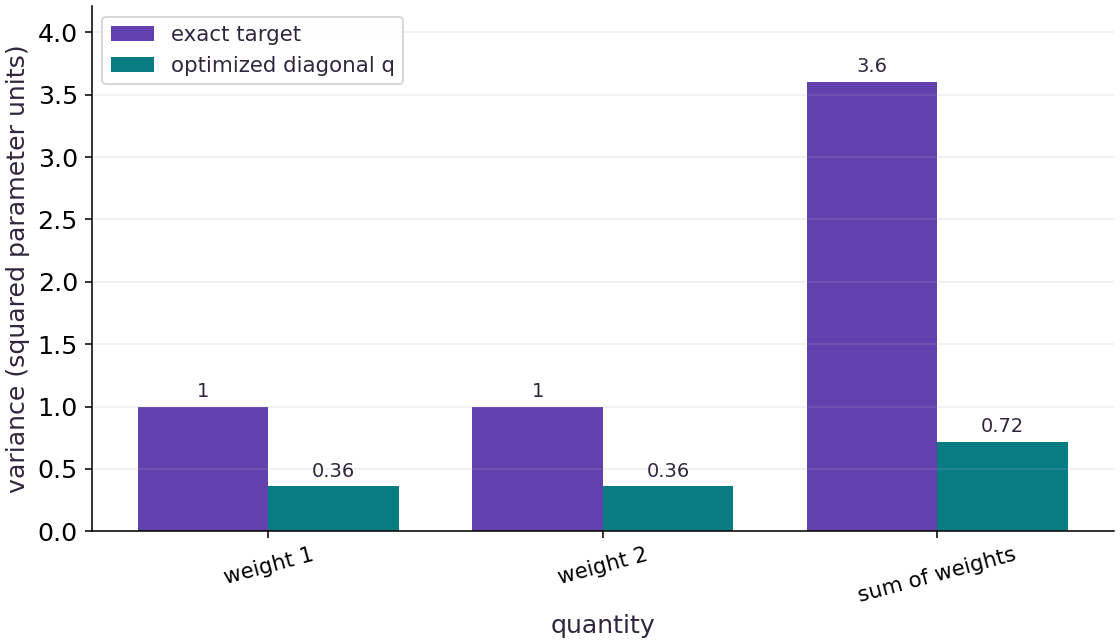

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data['unit'] in ('attention weight', 'next-token probability'):
            kw.update(vmin=0, vmax=1)
        device_ids = 'device ID' in data['unit']
        if device_ids:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            ids=np.unique(a).astype(int)
            kw.update(cmap=ListedColormap(palette[:len(ids)]), norm=BoundaryNorm(np.arange(ids.min()-0.5,ids.max()+1.5),len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if device_ids else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal categories identify three quantities: variance of the first weight, variance of the second weight and variance of their sum. The vertical axis is variance in squared parameter units. The target bars are $1,1,3.6$. The optimized diagonal approximation gives $0.36,0.36,0.72$. The especially large gap for the sum comes from both smaller marginal variances and missing positive covariance.

### Connect it to the computation

The code checks that the optimizer reaches the analytic variational optimum. The remaining gap therefore comes from the chosen diagonal family and KL direction on this particular Gaussian target. It is not evidence that every variational approximation has the same bias; a full-covariance Gaussian can represent this target.

## Monte Carlo KL through reparameterization

Predict: Will an estimate from diagonal-normal draws approach the exact KL even though the approximation is imperfect?

In [7]:
eps=jax.random.normal(jax.random.key(52),(40000,2))
z=location+jnp.exp(log_scale)*eps
delta=z-mu
logp=-.5*(jnp.einsum('ni,ij,nj->n',delta,P,delta)+2*jnp.log(2*jnp.pi)+jnp.linalg.slogdet(Sigma)[1])
logq=-.5*jnp.sum(eps**2,axis=1)-jnp.sum(log_scale)-jnp.log(2*jnp.pi)
estimate=jnp.mean(logq-logp)
assert abs(float(estimate-kl(params)))<.03
print('Monte Carlo KL:',float(estimate))

Monte Carlo KL: 0.5119153261184692


Expected: The estimate is close to the exact nonzero KL of $0.5108$.

Matching the exact KL validates this estimator on the fixture; it does not imply the approximate posterior is exact.

## Count model-generated intervals

Predict: Under the stated zero-mean normal model, what fraction of many replicated observations lies within 1.96 noise scales?

In [8]:
replicated=.25*jax.random.normal(jax.random.key(83),(40000,))
model_coverage=jnp.mean(jnp.abs(replicated)<=1.96*.25)
assert .94<model_coverage<.96
print("model self-coverage:",float(model_coverage))

model self-coverage: 0.9493999481201172


Expected: Approximately $95\%$ lie inside their model interval.

Self-coverage checks interval arithmetic under the model. It cannot establish coverage under the curved alternative.

## Your exercise

Replace the target correlation by zero and rederive the optimal diagonal variances and minimum KL. Verify that the diagonal family can now represent the target exactly.

In [9]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [10]:
def independent_kl(location,log_scale):
    return .5*(jnp.sum(jnp.exp(2*log_scale))+jnp.sum((location-mu)**2)-2-jnp.sum(2*log_scale))
assert jnp.allclose(independent_kl(mu,jnp.zeros(2)),0.)

## A correct diagonal is not a correct covariance · Transfer / diagnosis

Compare the variance of the sum of two target coordinates with that under the optimized diagonal approximation.

Hint: Retain the off-diagonal covariance terms in the target calculation.

In [11]:
# Write your attempt here.

## Reference reasoning

Joint predictions can reveal approximation error that examining means alone completely misses.

In [12]:
direction=jnp.ones(2)
true_sum_var=direction@Sigma@direction
approx_sum_var=jnp.sum(variance)
assert jnp.allclose(true_sum_var,3.6)
assert jnp.allclose(approx_sum_var,.72,atol=1e-5)

## Repair the changed mean without hiding noise · Transfer / diagnosis

Replace the zero mean by the known curved mean in the stress fixture. Draw fresh noisy targets and compare residual spread to the stated noise scale.

Hint: The fixture supplies the true curvature; real data would require fitting and held-out evaluation.

In [13]:
# Write your attempt here.

## Reference reasoning

Correcting the mean removes systematic residual structure in this known simulation; observation noise remains.

In [14]:
truth=jnp.linspace(-2,2,20000)**2-1
fresh=truth+.25*jax.random.normal(jax.random.key(95),(20000,))
residual=fresh-truth
assert abs(float(residual.std())-.25)<.01
assert abs(float(residual.mean()))<.01

## Checkpoint

The variational mean is correct and the optimization gradient is tiny. Why can posterior intervals still be too narrow?

1. The diagonal family cannot represent the correlated target, even at its optimum
2. Any Gaussian model necessarily produces wrong uncertainty
3. The number of optimizer iterations defines posterior variance

## Diagnose

If the objective has stopped improving, compare to the independent analytic optimum before adding iterations. If parameter uncertainty looks plausible but residuals show a U-shaped trend, investigate the mean model. If only one group is poorly covered, keep group-specific checks instead of relying on aggregate coverage.

## Evidence

Analytic and optimized KL, variance comparison, Monte Carlo estimate and explained residual stress fixture. Keep the environment, observed outputs and your explanation of the figure.

## Carry forward

- An optimized approximation can still miss posterior covariance.
- Model self-coverage is weaker than evaluation under changed observations.
- Keep inference diagnostics and posterior predictive checks as separate evidence.

## Primary references

- [Stan variational inference](https://mc-stan.org/docs/reference-manual/variational.html)
- [Stan posterior predictive checks](https://mc-stan.org/docs/stan-users-guide/posterior-predictive-checks.html)
- [NumPyro SVI interface](https://num.pyro.ai/en/stable/svi.html)